In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GCNConv
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    roc_curve
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\irene\Documents\SAPIENZA\TESI_GraphIDS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1) HeteroEdgeClassifier Model

class HeteroEdgeClassifier(nn.Module):
    def __init__(self, hidden_channels=64, out_channels=32, num_classes=2):
        super().__init__()

        self.conv1 = HeteroConv({
            ('ip', 'network', 'ip'): GCNConv(-1, hidden_channels),
            ('ip', 'context', 'ip'): GCNConv(-1, hidden_channels),
            ('ip', 'knowledge', 'ip'): GCNConv(-1, hidden_channels),
            #selected fetures
        }, aggr='sum')

        self.bn1_ip = nn.BatchNorm1d(hidden_channels)

        self.conv2 = HeteroConv({
            ('ip', 'network', 'ip'): GCNConv(hidden_channels, hidden_channels),
            ('ip', 'context', 'ip'): GCNConv(hidden_channels, hidden_channels),
            ('ip', 'knowledge', 'ip'): GCNConv(hidden_channels, hidden_channels),
            #selected fetures
        }, aggr='sum')

        self.bn2_ip = nn.BatchNorm1d(hidden_channels)

        self.lin_node = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels * 2),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_channels * 2, out_channels),
            nn.ReLU()
        )

        self.lin_edge = nn.Sequential(
            nn.Linear(out_channels * 2, out_channels),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(out_channels, out_channels),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(out_channels, num_classes)
        )

    def forward(self, data):
        x_dict = self.conv1(data.x_dict, data.edge_index_dict)
        x_dict['ip'] = self.bn1_ip(x_dict['ip'])
        x_dict['ip'] = F.relu(x_dict['ip'])

        x_dict = self.conv2(x_dict, data.edge_index_dict)
        x_dict['ip'] = self.bn2_ip(x_dict['ip'])
        x_dict['ip'] = F.relu(x_dict['ip'])

        x_dict['ip'] = self.lin_node(x_dict['ip'])
        return x_dict

    def edge_classify(self, z_src, z_dst):
        z_cat = torch.cat([z_src, z_dst], dim=-1)
        logits = self.lin_edge(z_cat)
        return logits

##############################
# 2) Focal Loss
##############################
def focal_loss(logits, targets, alpha=0.25, gamma=2.0):
    ce_loss = F.cross_entropy(logits, targets, reduction='none')
    pt = torch.exp(-ce_loss)
    return (alpha * (1 - pt)**gamma * ce_loss).mean()


In [3]:
##############################
# 3) Train Edge Classifier
##############################
def train_edge_classifier(model, graphs, epochs=10, device='cuda', alpha=0.25, gamma=2.0):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for data in graphs:
            data = data.to(device)
            optimizer.zero_grad()

            x_dict = model(data)
            z_ip = x_dict['ip']

            loss_graph = 0.0
            for rel_type in data.edge_types:
                if 'edge_label' not in data[rel_type]:
                    continue
                labels = data[rel_type].edge_label
                if labels.numel() == 0:
                    continue

                edge_index = data[rel_type].edge_index
                src, dst = edge_index
                logits = model.edge_classify(z_ip[src], z_ip[dst])

                loss_rel = focal_loss(logits, labels, alpha=alpha, gamma=gamma)
                loss_graph += loss_rel

            loss_graph.backward()
            optimizer.step()
            total_loss += loss_graph.item()

        avg_loss = total_loss / len(graphs)
        print(f"[Epoch {epoch}/{epochs}] Loss: {avg_loss:.4f}")


Using device: cpu
Loaded 3 training graphs.
[Epoch 1/70] Loss: 0.1403
[Epoch 2/70] Loss: 0.0982
[Epoch 3/70] Loss: 0.0580
[Epoch 4/70] Loss: 0.0297
[Epoch 5/70] Loss: 0.0151
[Epoch 6/70] Loss: 0.0073
[Epoch 7/70] Loss: 0.0042
[Epoch 8/70] Loss: 0.0030
[Epoch 9/70] Loss: 0.0023
[Epoch 10/70] Loss: 0.0019
[Epoch 11/70] Loss: 0.0016
[Epoch 12/70] Loss: 0.0014
[Epoch 13/70] Loss: 0.0013
[Epoch 14/70] Loss: 0.0012
[Epoch 15/70] Loss: 0.0012
[Epoch 16/70] Loss: 0.0011
[Epoch 17/70] Loss: 0.0010
[Epoch 18/70] Loss: 0.0011
[Epoch 19/70] Loss: 0.0011
[Epoch 20/70] Loss: 0.0009
[Epoch 21/70] Loss: 0.0010
[Epoch 22/70] Loss: 0.0010
[Epoch 23/70] Loss: 0.0010
[Epoch 24/70] Loss: 0.0009
[Epoch 25/70] Loss: 0.0008
[Epoch 26/70] Loss: 0.0007
[Epoch 27/70] Loss: 0.0009
[Epoch 28/70] Loss: 0.0010
[Epoch 29/70] Loss: 0.0008
[Epoch 30/70] Loss: 0.0010
[Epoch 31/70] Loss: 0.0008
[Epoch 32/70] Loss: 0.0009
[Epoch 33/70] Loss: 0.0010
[Epoch 34/70] Loss: 0.0009
[Epoch 35/70] Loss: 0.0010
[Epoch 36/70] Loss: 

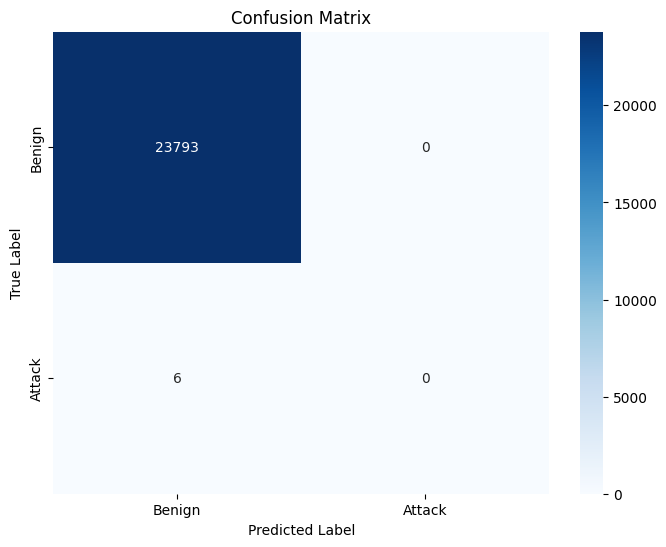

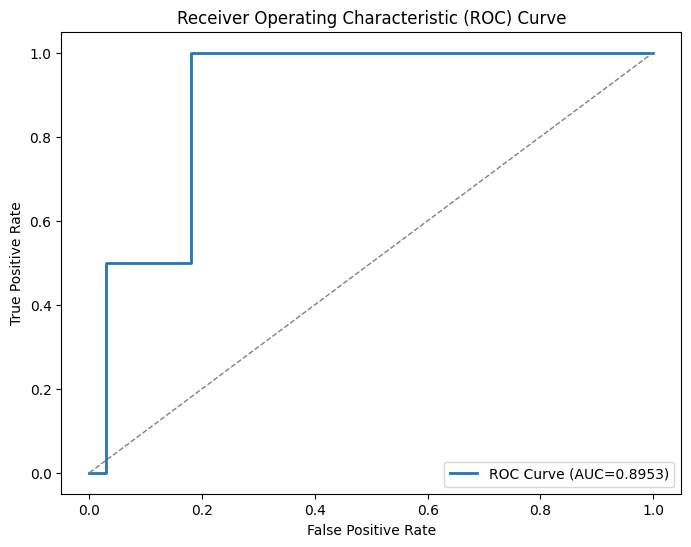

In [4]:
%matplotlib inline
################################
# 4) Evaluate Edge Classifier
################################
@torch.no_grad()
def evaluate_edge_classifier(model, test_graphs, device='cuda', threshold=0.5):
    model.eval()
    model.to(device)

    all_scores = []
    all_labels = []

    for data in test_graphs:
        data = data.to(device)
        x_dict = model(data)
        z_ip = x_dict['ip']

        for rel_type in data.edge_types:
            if 'edge_label' not in data[rel_type]:
                continue
            labels = data[rel_type].edge_label
            if labels.numel() == 0:
                continue

            edge_index = data[rel_type].edge_index
            src, dst = edge_index
            logits = model.edge_classify(z_ip[src], z_ip[dst])

            probs = F.softmax(logits, dim=-1)[:, 1]
            all_scores.extend(probs.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)

    if len(np.unique(all_labels)) < 2:
        print("Only one class in test set => AUC=0.5 by definition.")
        return

    auc = roc_auc_score(all_labels, all_scores)
    final_preds = (all_scores > threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, final_preds, average='binary', zero_division=0
    )
    accuracy = accuracy_score(all_labels, final_preds)
    cm = confusion_matrix(all_labels, final_preds)

    print(f"AUC={auc:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={accuracy:.4f}")
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.savefig("confusion_matrix.png")
    plt.show()

    fpr, tpr, _ = roc_curve(all_labels, all_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC={auc:.4f})", lw=2)
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.savefig("roc_curve.png")
    plt.show()

###############################
# 5) Data-Loading Helpers
###############################
def load_single_graph(directory, filename):
    path = os.path.join(directory, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found.")

    #data = torch.load(path)
    data = torch.load(path, weights_only=False)

    for rel_type in data.edge_types:
        if 'edge_label' in data[rel_type]:
            lbl = data[rel_type].edge_label
            lbl = torch.where(lbl < 0, torch.tensor(0, device=lbl.device), lbl)
            lbl = torch.where(lbl > 1, torch.tensor(1, device=lbl.device), lbl)
            data[rel_type].edge_label = lbl

    return data

#########################
# 6) Main Script
#########################
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    train_dir = "./hetero_graphs_pt"
    train_files = [f for f in os.listdir(train_dir) if f.endswith('.pt')]
    train_graphs = [load_single_graph(train_dir, f) for f in train_files]

    print(f"Loaded {len(train_graphs)} training graphs.")

    hidden_channels = 64
    out_channels = 32
    model = HeteroEdgeClassifier(hidden_channels, out_channels)

    train_edge_classifier(model, train_graphs, epochs=70, device=device)

    test_dir = "./3ed_tes_h_graphs_hetero_graphs"
    test_files = [f for f in os.listdir(test_dir) if f.endswith('.pt')]
    test_graphs = [load_single_graph(test_dir, f) for f in test_files]

    print(f"Loaded {len(test_graphs)} test graph(s).")

    best_threshold = 0.43
    evaluate_edge_classifier(model, test_graphs, device=device, threshold=best_threshold)
